## Fun-a-thon 

27-maj-2026; DST - Copenhagen


In [1]:
uv sync

Resolved 187 packages in 1ms
Checked 180 packages in 2ms


Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='code'>

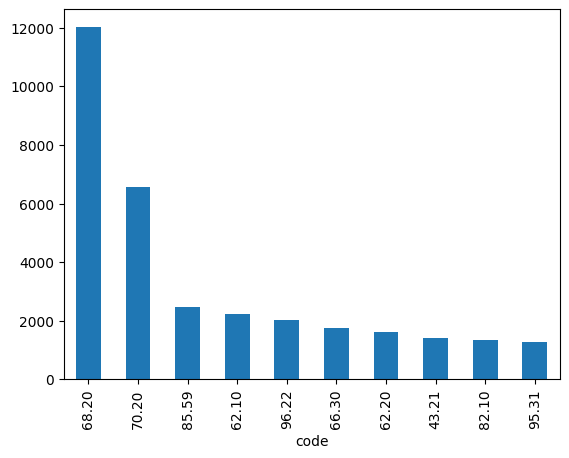

In [2]:
# %%
# If you need to change working directory (default is your interactive .py file location)
# import os
# os.chdir("<NEW_RELATIVE_LOCATION>")

import pandas as pd

df = pd.read_parquet(
    "https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet"
)
df.head()

# %%
df["code"].value_counts().head(10).plot(kind="bar")

In [3]:
import mlflow
from dotenv import load_dotenv
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torchTextClassifiers.value_encoder import ValueEncoder
from torchTextClassifiers.tokenizers import WordPieceTokenizer


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the data 
The dataset consists of synthetic labelled examples generated for the NACE rev 2.1 nomenclature. Each row contains a short text description (label) and the corresponding NACE code (code).

Exercice 1: Load the labelled dataset

#### 2.1 Question 1 — Import libraries and load environment variables
Import the package `mlflow` and the `load_dotenv` from the `dotenv` package. Then execute `load_dotenv(override=True)` to load your `.env` file.

In [4]:
import mlflow
from dotenv import load_dotenv

load_dotenv(override=True)

True

#### 2.2 Question 2 — Load the dataset from s3
Use `Polars` to load the parquet file directly from this public URL:

https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet

Print the first rows and the total number of observations. Do you understand all columns?

In [5]:
# importing Polars 
import polars as pl

# importing data
df = pl.read_parquet("https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet")

In [6]:
print(f"Printing the 1st rows of the dataset: {df.head()}")
print(f"\n")
print(f"total nr. of obs: {len(df)}")

Printing the 1st rows of the dataset: shape: (5, 3)
┌───────┬─────────────────────────────────┬─────────────────────────────────┐
│ code  ┆ name                            ┆ label                           │
│ ---   ┆ ---                             ┆ ---                             │
│ str   ┆ str                             ┆ str                             │
╞═══════╪═════════════════════════════════╪═════════════════════════════════╡
│ 01.11 ┆ Growing of cereals, other than… ┆ Pulses cultivation for market   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Legume crop production activit… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Broad bean farming operations   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Chickpea harvesting and proces… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Production of dried beans and … │
└───────┴─────────────────────────────────┴─────────────────────────────────┘


total nr. of obs: 70000


In [7]:
# view dataset
df

code,name,label
str,str,str
"""01.11""","""Growing of cereals, other than…","""Pulses cultivation for market"""
"""01.11""","""Growing of cereals, other than…","""Legume crop production activit…"
"""01.11""","""Growing of cereals, other than…","""Broad bean farming operations"""
"""01.11""","""Growing of cereals, other than…","""Chickpea harvesting and proces…"
"""01.11""","""Growing of cereals, other than…","""Production of dried beans and …"
…,…,…
"""82.10""","""Office administrative and supp…","""Business document preparation …"
"""82.10""","""Office administrative and supp…","""Letter and resume composition"""
"""82.10""","""Office administrative and supp…","""Administrative support on a fe…"


#### 2.3 Question 3 — Count unique NACE codes
How many unique NACE codes are present in the dataset? Store this number in a variable called `n_classes`. This number will define the number of output classes the model must predict.

In [8]:
# variable n_classes
# datasetName['varName'].n_unique()
# n_unique()
n_classes = df['code'].n_unique()
print(f"nr. of unique NACE codes:", n_classes)

nr. of unique NACE codes: 311


### 3 Split the data
Before training a model, we need to split the dataset into three subsets:

<ul>
    <li>Train: the examples the model learns from.</li>
    <li>Validation: used during training to monitor performance and trigger early stopping (i.e. stop training before overfitting).</li>
    <li>Test: held out until the very end to give an unbiased estimate of the model’s performance on unseen data.</li>
</ul>



Why three splits and not two?
Using the validation set to tune hyperparameters or stop training means it indirectly influences the model. The test set must therefore remain completely untouched during training so that the final evaluation is truly unbiased.

Exercice 2: Prepare the data

#### 3.1 Question 1 — Split the dataset into train / validation / test sets
Use `train_test_split` from `sklearn.model_selection` to split the dataset into train, validation, and test sets (70% / 15% / 15%). Do not forget to choose a `random_state`. Separate the target `y` from the features `X`, and convert them to `numpy arrays`. You should obtain objects `X_train`, `y_train`, and so on.

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# split the data into train
# train_df, tmp_df = train_test_split(datasetName, test_size = nr, random_state = nr)
# test_size = 0.3 --> resten of the data goes to train dataset
# random_state: controls the shuffling applied to the data
train_df, tmp_df = train_test_split(df, test_size = 0.30, random_state = 42)
val_df, test_df = train_test_split(tmp_df, test_size=0.5, random_state=42)

In [11]:
print(f"nr. obs train dataset: {len(train_df)}")
print(f"nr. obs tmp dataset: {len(tmp_df)}")
print(f"nr. obs validering dataset: {len(val_df)}")
print(f"nr. obs test dataset: {len(test_df)}")


nr. obs train dataset: 49000
nr. obs tmp dataset: 21000
nr. obs validering dataset: 10500
nr. obs test dataset: 10500


In [12]:

# Separating the target y from feature X and convert to numpy arrays
# in the training dataset
X_train, y_train = train_df["label"].to_numpy(), train_df["code"].to_numpy()
# in the validation dataset
X_val, y_val = val_df["label"].to_numpy(), val_df["code"].to_numpy()
# in the test dataset
X_test, y_test = test_df["label"].to_numpy(), test_df["code"].to_numpy()

In [13]:
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 49000 | Val: 10500 | Test: 10500


In [14]:
type(train_df["label"])
type(X_train)

numpy.ndarray

#### 3.2 Question 2 — Encode the labels
The `code` column contains strings like `"47.11A"` (codes from the NACE classification). Neural networks do not understand strings and require integer targets (1, 2, 3…), so we need to map each unique NACE code to an integer index. To do that, you will use an encoder.

Use `LabelEncoder` from `sklearn.preprocessing` (see here (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) for the documentation). Call `.fit()` on the `code` column of your training dataframe (after having converted it to a numpy array with `.to_numpy()`).

Note: Why do we use LabelEncoder?
We use `LabelEncoder` to map the categorical target `y` to integers `0, 1, …, n_classes - 1`, the format expected by scikit-learn classifiers.

In [15]:
# checking 
all_codes = set(df['code'])
all_codes

train_codes = set(train_df['code'])
missing_codes = all_codes - train_codes

if missing_codes: 
    print(f"WARNING: {len(missing_codes)} code(s) missing from training set: {missing_codes}")
else:
    print(f"OK - all {len(all_codes)} code(s) appear training set")

OK - all 311 code(s) appear training set


In [16]:
# The categorical target y - corresponds to code - is now mapped to 0,1,... n_classes-1 by using LabelEncoder
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# fits the label encoder. The parameter is the target value, in our case it is var Code in the train dataset
# in addition we turn the result  to numpy arrays
encoder.fit(train_df['code'].to_numpy())


LabelEncoder()

In [17]:
type(encoder)

sklearn.preprocessing._label.LabelEncoder

#### 3.3 Question 3 — Prepare the labels to use them with ttc
`torchTextClassifiers` requires labels to be wrapped in a `ValueEncoder` object. This is straightforward: you just pass your already-fitted `LabelEncoder` to the `ValueEncoder` constructor.

Import the `ValueEncoder` class from the `torchTextClassifiers.value_encoder` subpackage, then create a `value_encoder` object by passing your fitted `label_encoder` as an argument.

In [18]:
%pip install git+https://github.com/InseeFrLab/torchTextClassifiers.git

  Cloning https://github.com/InseeFrLab/torchTextClassifiers.git to /tmp/pip-req-build-qwr1q1wg
  Running command git clone --filter=blob:none --quiet https://github.com/InseeFrLab/torchTextClassifiers.git /tmp/pip-req-build-qwr1q1wg
  Resolved https://github.com/InseeFrLab/torchTextClassifiers.git to commit 9a8b215dde66d6d549f4e479899edbb7c287fc12
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.



Note: Why wrap the LabelEncoder in a ValueEncoder?
While `LabelEncoder` plays the role of the “converter” from string labels to integers, working with raw integers at prediction time can be cumbersome — you have to manually map predictions back to their original label names. The `ValueEncoder` solves this by integrating tightly with the `torchTextClassifiers` ecosystem: when you pass it to a model, predictions are automatically returned as human-readable labels rather than integers. As a bonus, `ValueEncoder` also supports additional categorical input features — advanced readers can find examples here (https://inseefrlab.github.io/torchTextClassifiers/tutorials/mixed_features.html).

In [19]:
from torchTextClassifiers.value_encoder import ValueEncoder

In [20]:
value_encoder = ValueEncoder(label_encoder = encoder)
value_encoder

## 4 Applying a tokenizer

#### 4.1 Why tokenization?
Neural networks can only work with numbers because they have no notion of letters or words. As a a consequence, models cannot use directly the string “I sell croissants and pains au chocolat” to predict a NACE code, it must be transformed into something the model can use. A tokenizer is the component that bridges this gap: it converts raw text into a sequence of integers that the model can process.

The process has three steps:
<ul>
    <li>Split the text into small units called tokens: these can be whole words, subword fragments, or individual characters.</li>
    <li>Map each token to a unique integer using a fixed vocabulary (a lookup table built during training). </li>
    <li>Pad or truncate the resulting sequence to a fixed length so that all inputs have the same shape, which is required for batched training. </li>
</ul>

#### 4.2 Why subword tokenization?
There are several ways to split text into tokens: by character, by full word, or by subword fragment. Each has trade-offs:

Strategy	Example for “croissants”	Problem
Character-level	`["c","r","o","i","s","s","a","n","t","s"]`	Sequences become very long; meaning is hard to capture
Word-level	["croissants"]	Rare or misspelled words get mapped to `[UNKNOWN]`
Subword (WordPiece)	`["croi", "##ssants"]`	Handles rare words without losing common subparts
WordPiece, the algorithm used here, builds a vocabulary of frequent subword units from the training corpus. Words it has never seen can still be represented by combining known fragments. The `##` prefix marks a fragment that continues the previous token (i.e. it is not the start of a new word).

Because the vocabulary is learned from your data, it naturally adapts to domain-specific vocabulary; in our case, French business descriptions full of technical terms.

#### 4.3 Question 1 — Train the tokenizer and inspect a sample
You are going to use a `WordPieceTokenizer` from the `torchTextClassifiers` package (see the documentation (https://inseefrlab.github.io/torchTextClassifiers/api/tokenizers.html)). Train a `WordPieceTokenizer` from scratch on the training labels with `vocab_size=5000` and `output_dim=10`. Use the fitted tokenizer to tokenize one observations (with the `tokenize` method), and inspect the result to understand how the text is split.

Clue here
Instantiate `WordPieceTokenizer(vocab_size=5000, output_dim=10)` and call `.train(X_train)`. Use `.tokenize()` and `.convert_ids_to_tokens()` to inspect a sample.


Warning: Tokenizer data leakage
Always train the tokenizer on `X_train` only — never on the validation or test sets. Using the full dataset would mean the tokenizer has seen vocabulary from examples the model is supposed to predict.

In [21]:
!pip install tokenizers transformers

In [22]:
import sys
import traceback

print("Python:", sys.executable)
print()

try:
    from tokenizers import Tokenizer
    print("tokenizers import: OK")
except Exception:
    print("tokenizers import: FAILED")
    traceback.print_exc()

print()

try:
    from transformers import AutoTokenizer, PreTrainedTokenizerFast
    print("transformers import: OK")
except Exception:
    print("transformers import: FAILED")
    traceback.print_exc()




import sys

for module_name in list(sys.modules):
    if module_name == "torchTextClassifiers.tokenizers" or module_name.startswith(
        "torchTextClassifiers.tokenizers."
    ):
        del sys.modules[module_name]




Python: /opt/python/bin/python

tokenizers import: OK

transformers import: OK


In [23]:
from torchTextClassifiers.tokenizers import HAS_HF, WordPieceTokenizer

print("HAS_HF:", HAS_HF)

tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)

HAS_HF: True


WordPieceTokenizer
Use when:
<ul> 
    <li> You want subword-level features</li>
    <li> Your vocabulary is large but manageable </li>
    <li> You need good coverage with reasonable vocab size </li>
    <li> You’re doing standard text classification </li>
</ul>

In [24]:
from torchTextClassifiers.tokenizers import WordPieceTokenizer

In [25]:
# vocab_size=5000: How many unique WordPiece tokens exist
# output_dim=10: the number of output labels/classes
tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)

In [26]:
print("Output tensor size:", tokenizer.tokenize(X_train[0]).input_ids.shape)
print("Vocabulary size:", tokenizer.vocab_size)

# Look at an example of tokenization
print("Raw text", X_train[0])
print(
    "Tokens id:",
    tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
)
print(
    "Tokens:",
    tokenizer.tokenizer.convert_ids_to_tokens(
        tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
    )
)

Output tensor size: torch.Size([1, 10])
Vocabulary size: 5000
Raw text Real estate portfolio management
Tokens id: tensor([  3, 190, 206, 317, 137,   2,   1,   1,   1,   1])
Tokens: ['[SEP]', 'real', 'estate', 'portfolio', 'management', '[CLS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [27]:
X_train[0]

'Real estate portfolio management'

#### 5 Model architecture
A text classification model in `torchTextClassifiers` is built from three components (on top of the `ValueEncoder` and the tokenizer seen above):

TextEmbedder: converts token IDs into dense vectors (embeddings) of size `embedding_dim`.
NoteEmbeddings, a key concept in NLP models
CategoricalVariableNet (optional): encodes additional categorical features and merges them with the text representation. Not used here.

ClassificationHead: projects the final representation onto num_classes dimensions. The highest value determines the predicted class.

To learn more about the building blocks of the torchTextClassifiers package, please visit the documentation (https://inseefrlab.github.io/torchTextClassifiers/architecture/index.html).

These are configured through `ModelConfig` and assembled automatically by `torchTextClassifiers`. You can see some `ModelConfig` examples here (https://inseefrlab.github.io/torchTextClassifiers/architecture/overview.html#usage-examples) and for `torchTextClassifiers` here (https://inseefrlab.github.io/torchTextClassifiers/api/wrapper.html).

#### 6 Training
Training a neural network means finding the weights that minimise a loss function — a measure of how wrong the model’s predictions are. At each step, the model makes predictions on a mini-batch of examples, computes the loss, and updates the weights in the direction that reduces it (via an optimization algorithm called the stochastic gradient descent).

[IMAGE]

<ul>
    <li> num_epochs: how many times the model sees the full training set. </li>
    <li> batch_size: how many examples are processed at once before a weight update.</li>
    <li> lr (learning rate): how large each weight update step is.</li>
    <li> patience_early_stopping: stop training if the validation loss has not improved for this many epochs, to avoid overfitting.</li>
</ul>

#### Exercice 4: Train the model
`torchTextClassifiers` provides a high-level wrapper that combines the value encoder, tokenizer, model components, and training loop. You will do two things: create a model, and then train the model. It is important to distinguish these two steps clearly. To do so, `torchTextClassifiers` offers two tools: `ModelConfig` defines the model and `TrainingConfig` defines the training process.

#### 6.1 Question 1 — Create the classifier
Using the `torchTextClassifiers` package, create a `ModelConfig`. Then create a `torchTextClassifiers` classifier that uses this `ModelConfig` and the trained tokenizer. Set the dimension of embeddings to 96. You will need to read carefully the `torchTextClassifiers` documentation.

Clue here
Build a `ModelConfig` with `embedding_dim` and `num_classes`. Pass both to `torchTextClassifiers(tokenizer=..., model_config=..., value_encoder=...)`.

In [28]:
from torchTextClassifiers import ModelConfig, TrainingConfig, torchTextClassifiers

In [29]:
# provided in the exercise description
# Key parameter: The hyperparameter embedding_dim controls the size of the dense vector representing each token. 
# Larger values capture more information but are slower to train.
embedding_dim = 96

In [30]:
# Creating the ModelConfig
model_config = ModelConfig(
    # Dimension of text embeddings
    embedding_dim = embedding_dim,
    # Number of output classes (optional, inferred from data if not provided)
    # in our case is the 311 NACE codes
    num_classes = n_classes)

In the next python code:

Generic text classifier framework supporting multiple architectures.

Given a tokenizer and model configuration, this class initializes: - Text embedding layer (if needed) - Categorical variable embedding network (if categorical variables are provided) - Classification head The resulting model can be trained using PyTorch Lightning and used for predictions.

In [31]:
# torchTextClassifiers that uses the ModelConfig we just made
# Her we are initializing the model
ttc = torchTextClassifiers(
    tokenizer = tokenizer,
    model_config = model_config,
    value_encoder = value_encoder
)

2026-05-27 13:51:15 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.


#### 6.2 Question 2 — Prepare training
Create a `TrainingConfig(lr=..., batch_size=..., num_epochs=...)`. Look at the documentation (https://inseefrlab.github.io/torchTextClassifiers/api/configs.html#trainingconfig). Do you understand what each argument does? Use only 1 epoch for fast training.

Play with hyperparameters
Of course, you can play with hyperparameters if you want: add more epochs, change the learning rate and the batch size… But **remember that you are training the model using CPUs, so avoid big models that will take a lot of time and resources to train**

Want to learn what hyperparameters do?
Key hyperparameters used here:

<ul>
    <li>`lr=5e-4`: a standard starting learning rate for Adam-based optimizers.</li>
    <li>`batch_size=128`: how many examples are processed before each weight update — larger batches are faster but require more memory.</li>
    <li>`num_epochs=1: one pass over the data, kept short for this demo.</li>
</ul>

In [32]:
training_configuration = TrainingConfig(
    num_epochs = 1,             # Number of training epochs - how many times the model sees the full training set.
    batch_size = 128,           # Batch size for training (int) - how many examples are processed at once before a weight update
    lr=5 * 1e-4,                # learining rate (a float) - how large each weight update step is
    patience_early_stopping=5   # Early stopping patience in epochs (default: 3)
)

#### 6.3 Question 3 — Train on a small subsample
Train the model using the `TrainingConfig` defined before. Look carefully at the arguments of the `train` method. You can try to use MLflow or automatic model logging, but this is optional (see below).

Clue here
`Call ttc.train(X_train=..., y_train=..., X_val=..., y_val=..., training_config=..., verbose=True)`.

Logging training with MLflow
Use `mlflow.pytorch.autolog()` and wrap your training call in `mlflow.start_run()` to automatically log metrics (loss, accuracy) to an MLflow experiment:

mlflow.set_experiment("my-experiment")
mlflow.pytorch.autolog()

with mlflow.start_run():
    ttc.train(...)

`mlflow.set_experiment(...)`: sets the active experiment (created automatically if it does not exist).
Each call inside `mlflow.start_run()` creates a new run inside that experiment, so successive training attempts are kept separate and comparable.
If `MLFLOW_TRACKING_URI` is set in your environment (e.g. via `.env`), metrics are forwarded to that remote server automatically.

In [33]:
mlflow.set_experiment("funathon-2026-project2")
mlflow.pytorch.autolog()

with mlflow.start_run() as run:
    # This should take approximately 1-2mn
    ttc.train(
        X_train,
        y_train,
        training_config=training_configuration,
        X_val=X_val,
        y_val=y_val,
        verbose=True,
    )

    mlflow.log_artifacts(
        training_configuration.save_path,   # local folder produced by ttc.train()
        artifact_path="model_artifacts",
    )

2026-05-27 13:51:15 - torchTextClassifiers.torchTextClassifiers - Starting training process...
2026-05-27 13:51:15 - torchTextClassifiers.torchTextClassifiers - Running on: cpu
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/opt/python/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments pla

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ TextClassificationModel │  510 K │ train │     0 │
│ 1 │ loss        │ CrossEntropyLoss        │      0 │ train │     0 │
│ 2 │ accuracy_fn │ MulticlassAccuracy      │      0 │ train │     0 │
└───┴─────────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 510 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 510 K                                                                                                
Total estimated model params size (MB): 2.041                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/python/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` 
from an ambiguous collection. The batch size we found is 104. To avoid any miscalculations, use `self.log(..., 
batch_size=batch_size)`.

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` 
from an ambiguous collection. The batch size we found is 4. To avoid any miscalculations, use `self.log(..., 
batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=1` reached.


2026/05/27 13:52:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/27 13:52:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/onyxia/work/funathon-project2
2026/05/27 13:52:08 INFO mlflow.utils.environment: Detected uv project at /home/onyxia/work/funathon-project2. Attempting to export requirements via 'uv export'.
2026/05/27 13:52:08 INFO mlflow.utils.uv_utils: Exported 186 dependencies via uv
2026/05/27 13:52:08 INFO mlflow.utils.environment: Successfully exported 186 requirements from uv project. Skipping package capture based inference.
2026/05/27 13:52:08 INFO mlflow.utils.uv_utils: Extracted 1 private index URL(

🏃 View run mysterious-sloth-413 at: https://user-imcdk-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/fa41ef8cef26482abef90312bd75e16d
🧪 View experiment at: https://user-imcdk-mlflow.user.lab.sspcloud.fr/#/experiments/1


In [34]:
#| label: load-from-run
#| code-overflow: scroll
#| output: true
local_dir = mlflow.artifacts.download_artifacts(
    f"runs:/{run.info.run_id}/model_artifacts"
)

# Rebuild the torchTextClassifiers object from the downloaded files
ttc_loaded = torchTextClassifiers.load(local_dir)

print(ttc_loaded)

2026-05-27 13:52:16 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.
2026-05-27 13:52:16 - torchTextClassifiers.torchTextClassifiers - Model checkpoint loaded from /tmp/tmp2gubt3lr/model_artifacts/model_checkpoint.ckpt
2026-05-27 13:52:16 - torchTextClassifiers.torchTextClassifiers - Model loaded successfully from /tmp/tmp2gubt3lr/model_artifacts


torchTextClassifiers(
  tokenizer = WordPieceTokenizer 
 HuggingFace tokenizer: TokenizersBackend(name_or_path='', vocab_size=5000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'pad_token': '[PAD]'}, added_tokens_decoder={
	0: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}),
  model = TextClassificationModule(
  (model): TextClassificationModel(
    (token_embedder): TokenEmbedder(
      (embedding_layer): Embedding(5000, 96, padding_idx=1)
    )
    (sentence_embedder): SentenceEmbedder()
    (classification_head): ClassificationHead(
      (net): Linear(in_

In [35]:


ttc.pytorch_model.eval()


TextClassificationModel(
  (token_embedder): TokenEmbedder(
    (embedding_layer): Embedding(5000, 96, padding_idx=1)
  )
  (sentence_embedder): SentenceEmbedder()
  (classification_head): ClassificationHead(
    (net): Linear(in_features=96, out_features=311, bias=True)
  )
)

In [36]:
import s3fs

fs = s3fs.S3FileSystem(
    anon=True,  # public bucket
    endpoint_url="https://minio.lab.sspcloud.fr",
)

local_dir = "./mlflow-artifacts/"
fs.get(
    "projet-funathon/diffusion/mlflow-artifacts/",
    local_dir,
    recursive=True,
)
# Rebuild the torchTextClassifiers object from the downloaded files
ttc = torchTextClassifiers.load(local_dir)

ttc.pytorch_model.eval()

2026-05-27 13:52:16 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.
2026-05-27 13:52:17 - torchTextClassifiers.torchTextClassifiers - Model checkpoint loaded from mlflow-artifacts/model_checkpoint.ckpt
2026-05-27 13:52:17 - torchTextClassifiers.torchTextClassifiers - Model loaded successfully from mlflow-artifacts


TextClassificationModel(
  (token_embedder): TokenEmbedder(
    (embedding_layer): Embedding(5000, 96, padding_idx=1)
  )
  (sentence_embedder): SentenceEmbedder(
    (label_attention_module): LabelAttention(
      (label_embeds): Embedding(311, 96)
      (c_q): Linear(in_features=96, out_features=96, bias=False)
      (c_k): Linear(in_features=96, out_features=96, bias=False)
      (c_v): Linear(in_features=96, out_features=96, bias=False)
      (c_proj): Linear(in_features=96, out_features=96, bias=False)
    )
  )
  (classification_head): ClassificationHead(
    (net): Linear(in_features=96, out_features=1, bias=True)
  )
)

In [37]:
pip install Captum 

Note: you may need to restart the kernel to use updated packages.


In [39]:
import random

random_indices = random.sample(range(len(X_test)), 3)
example_texts = X_test[random_indices]
example_true_codes = y_test[random_indices]
print(example_texts)
type(example_texts)

['Vehicle maintenance and servicing operations'
 'Leasing of facilities for photovoltaic systems'
 'Operation of Turkish bath facilities']


numpy.ndarray

In [40]:
top_k = 5
results = ttc.predict(example_texts, top_k=top_k, explain_with_captum=True)

TypeError: Expected TokenizerOutput, got <class 'torchTextClassifiers.tokenizers.base.TokenizerOutput'> from tokenizer.tokenize method.

In [ ]:


for i, text in enumerate(example_texts):
    predicted_codes = [results["prediction"][i][k] for k in range(top_k)]
    confidence = [results["confidence"][i][k].item() for k in range(top_k)]
    print(f"\nText: {text}")
    print(f"  True code: {example_true_codes[i]}")
    for code, conf in zip(predicted_codes, confidence):
        print(f"  {code}  (confidence: {conf:.3f})")

['Management of forestry land for revenue'
 'Mobile home park site operation' 'Pension scheme asset oversight']


TypeError: Expected TokenizerOutput, got <class 'torchTextClassifiers.tokenizers.base.TokenizerOutput'> from tokenizer.tokenize method.

type(example_texts)